In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
import seaborn as sns
import pandas as pd
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups_vectorized
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import random
import gzip 

# Ví dụ B.1

In [74]:
# randomly generate data
N = 500 # number of training sample
d = 2 # data dimension
C = 3 # number of classes (for c = 0, 1, 2)
means = [[2, 2], [8, 3], [3, 6]] # centeroid of each class dataset
cov = [[1, 0], [0, 1]]
# generate 3 classes of datasets
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)
# each column is a datapoint (arrange 3 vectors X1 X2 X3 then transpose matrix)
X = np.concatenate((X0, X1, X2), axis = 0).T
# extended data by add row ONES (equivalent to 1) at first place
X = np.concatenate((np.ones((1, 3*N)), X), axis = 0)

# Generate label for data points of each class (0, 1, 2)
# with first 500 will belong to class 0, second 500 => 1 and last 500=> class 2
original_label = np.asarray([0]*N + [1]*N + [2]*N).T

In [75]:
def convert_labels(y, C = C):
    """
    convert 1d label to a matrix label: each column of this
    matrix coresponding to 1 element in y. In i-th column of Y,
    only one non-zeros element located in the y[i]-th position,
    and = 1 ex: y = [0, 2, 1, 0], and 3 classes then return

    [[1, 0, 0, 1],
    [0, 0, 1, 0],
    [0, 1, 0, 0]]
    """
    Y = sparse.coo_matrix((np.ones_like(y),
        (y, np.arange(len(y)))), shape = (C, len(y))).toarray()
    return Y

    # Y = convert_labels(original_label, C)

In [76]:
def softmax_stable(Z):
    """
    Compute softmax values for each sets of scores in Z.
    each column of Z is a set of score.
    """
    e_Z = np.exp(Z - np.max(Z, axis = 0, keepdims = True))
    A = e_Z / e_Z.sum(axis = 0)
    return A
def softmax(Z):
    """
    #Compute softmax values for each sets of scores in V.
    #each column of V is a set of score.
    """
    e_Z = np.exp(Z)
    A = e_Z / e_Z.sum(axis = 0)
    return A
def softmax_regression(X, y, W_init, eta, tol = 1e-4, max_count = 10000):
    W = [W_init]
    C = W_init.shape[1]
    Y = convert_labels(y, C)
    it = 0
    N = X.shape[1]
    d = X.shape[0]

    count = 0
    check_w_after = 20
    while count < max_count:
        # mix data
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = Y[:, i].reshape(C, 1)
            ai = softmax(np.dot(W[-1].T, xi))
            W_new = W[-1] + eta*xi.dot((yi - ai).T)
            count += 1
        # stopping criteria
            if count%check_w_after == 0:
                if np.linalg.norm(W_new - W[-check_w_after]) < tol:
                    return W
            W.append(W_new)
    return W

In [77]:
def cost(X, Y, W):
    A = softmax(W.T.dot(X))
    return -np.sum(Y*np.log(A))

# Predict that X belong to which class (1..C now indexed as 0..C-1 )
def pred(W, X):
    """
    predict output of each columns of X
    Class of each x_i is determined by location of max probability
    Note that class are indexed by [0, 1, 2, ...., C-1]
    """
    A = softmax_stable(W.T.dot(X))
    return np.argmax(A, axis = 0)
# W[-1] is the solution, W is all history of weights
eta = .05
d = X.shape[0]
W_init = np.random.randn(X.shape[0], C)
W = softmax_regression(X, original_label, W_init, eta)
print(W[-1])

[[ 8.71735875 -3.73627023 -3.05539359]
 [-0.93100866  1.70924282 -0.71926657]
 [-1.6644295  -1.65105653  1.52526998]]


(1, 270400)
(3, 270400)


array([[1.75663689, 2.87863476, 1.79888211, ..., 2.27365104, 3.09505574,
        1.03496319],
       [3.36132913, 1.26343618, 1.09358107, ..., 6.52971661, 6.14573917,
        5.61670146]], shape=(2, 1500))

array([0, 0, 0, ..., 2, 2, 2], shape=(1500,))

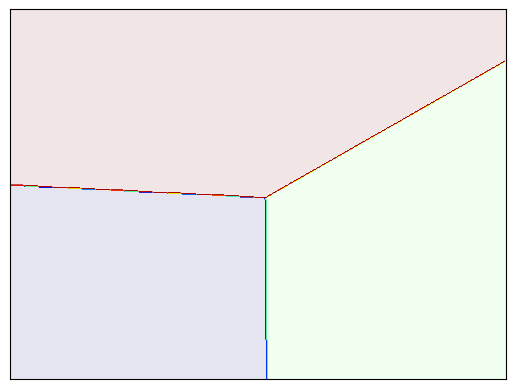

In [78]:
#Visualize
xm = np.arange(-2, 11, 0.025)
xlen = len(xm)
ym = np.arange(-3, 10, 0.025)
ylen = len(ym)
xx, yy = np.meshgrid(xm, ym)
print(np.ones((1, xx.size)).shape)
xx1 = xx.ravel().reshape(1, xx.size)
yy1 = yy.ravel().reshape(1, yy.size)
XX = np.concatenate((np.ones((1, xx.size)), xx1, yy1), axis = 0)
print(XX.shape)
Z = pred(W[-1], XX)
Z = Z.reshape(xx.shape)
CS = plt.contourf(xx, yy, Z, 200, cmap='jet', alpha = .1)
plt.xlim(-2, 11)
plt.ylim(-3, 10)
plt.xticks(())
plt.yticks(())
display(X[1:, :], original_label)
plt.savefig('ex1.png', bbox_inches='tight', dpi = 300)
plt.show()

# Ví dụ B.2

## Bài tập thực hành 1

In [79]:
iris = sns.load_dataset('iris')
label_map = {name: idx for idx, name in enumerate(sorted(iris['species'].unique()))}
iris['label'] = iris['species'].map(label_map)

# X là 4 đặc trưng tiêu chuẩn của IRIS
X_iris = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].to_numpy()
y_iris = iris['label'].to_numpy()

# Chuẩn hoá đặc trưng (z-score)
X_mean = X_iris.mean(axis=0, keepdims=True)
X_std = X_iris.std(axis=0, keepdims=True) + 1e-8
X_iris_std = (X_iris - X_mean) / X_std

# Chia 4:1 theo từng lớp
rs = np.random.RandomState(42)
train_idx, val_idx = [], []
for cls in np.unique(y_iris):
    idx = np.where(y_iris == cls)[0]
    rs.shuffle(idx)
    n_train = int(np.round(0.8 * len(idx)))
    train_idx.extend(idx[:n_train])
    val_idx.extend(idx[n_train:])

train_idx = np.array(train_idx)
val_idx = np.array(val_idx)

# Tạo ma trận X theo định dạng
X_train_iris = X_iris_std[train_idx]
X_val_iris = X_iris_std[val_idx]
y_train_iris = y_iris[train_idx]
y_val_iris = y_iris[val_idx]

X_train_iris = np.concatenate([np.ones((X_train_iris.shape[0], 1)), X_train_iris], axis=1).T
X_val_iris = np.concatenate([np.ones((X_val_iris.shape[0], 1)), X_val_iris], axis=1).T

print('Train shape:', X_train_iris.shape, '| Val shape:', X_val_iris.shape)

Train shape: (5, 120) | Val shape: (5, 30)


In [80]:
# 2) Huấn luyện bằng softmax tự cài đặt và đánh giá
C_iris = len(np.unique(y_iris))
eta_iris = 0.05
W_init_iris = np.random.randn(X_train_iris.shape[0], C_iris)

W_hist_iris = softmax_regression(X_train_iris, y_train_iris, W_init_iris, eta_iris)
W_star_iris = W_hist_iris[-1]

# Dự đoán trên tập validation (mỗi cột là 1 mẫu)
y_val_pred = pred(W_star_iris, X_val_iris)
acc_iris = (y_val_pred == y_val_iris).mean()
print('Validation accuracy:', f"{acc_iris:.4f}")

# Ma trận nhầm lẫn đơn giản
conf = np.zeros((C_iris, C_iris), dtype=int)
for t, p in zip(y_val_iris, y_val_pred):
    conf[t, p] += 1
print('Confusion matrix (rows=true, cols=pred):\n', conf)

Validation accuracy: 0.9667
Confusion matrix (rows=true, cols=pred):
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [81]:
# 3) Naive Bayes (GaussianNB) trên cùng split 4:1
# Chuẩn bị dữ liệu cho NB: dạng (n_samples, n_features), bỏ hàng bias ở đầu
X_train_nb = X_train_iris[1:, :].T  # (n_train, 4)
X_val_nb = X_val_iris[1:, :].T      # (n_val, 4)

nb_iris = GaussianNB()
nb_iris.fit(X_train_nb, y_train_iris)

y_val_pred_nb = nb_iris.predict(X_val_nb)
acc_nb_iris = (y_val_pred_nb == y_val_iris).mean()
print('Naive Bayes validation accuracy:', f"{acc_nb_iris:.4f}")

conf_nb = np.zeros((C_iris, C_iris), dtype=int)
for t, p in zip(y_val_iris, y_val_pred_nb):
    conf_nb[t, p] += 1
print('NB Confusion matrix (rows=true, cols=pred):\n', conf_nb)

Naive Bayes validation accuracy: 0.9667
NB Confusion matrix (rows=true, cols=pred):
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [82]:
rows = []
rows.append({'Model': 'Softmax (custom)', 'Val Accuracy': float(acc_iris)})
rows.append({'Model': 'Naive Bayes (GaussianNB)', 'Val Accuracy': float(acc_nb_iris)})

cmp_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(cmp_df)
print('Better model:', cmp_df.loc[0, 'Model'])

,Model,Val Accuracy
0,Softmax (custom),0.966667
1,Naive Bayes (GaussianNB),0.966667


Better model: Softmax (custom)


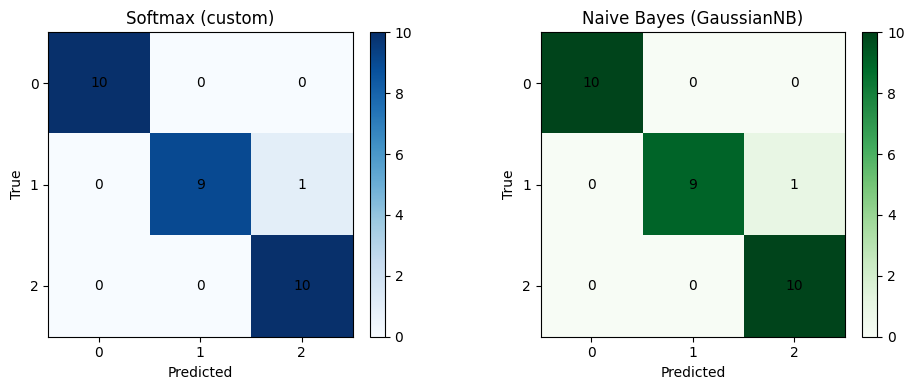

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Softmax
im0 = axes[0].imshow(conf, cmap='Blues', interpolation='nearest')
axes[0].set_title('Softmax (custom)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_xticks(np.arange(C_iris))
axes[0].set_yticks(np.arange(C_iris))
for i in range(C_iris):
    for j in range(C_iris):
        axes[0].text(j, i, conf[i, j], ha='center', va='center', color='black')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Naive Bayes
im1 = axes[1].imshow(conf_nb, cmap='Greens', interpolation='nearest')
axes[1].set_title('Naive Bayes (GaussianNB)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_xticks(np.arange(C_iris))
axes[1].set_yticks(np.arange(C_iris))
for i in range(C_iris):
    for j in range(C_iris):
        axes[1].text(j, i, conf_nb[i, j], ha='center', va='center', color='black')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Ví dụ B.3. (Bài tập thực hành 2)

In [11]:
n_samples = 20000
X, y = fetch_20newsgroups_vectorized(subset='all', return_X_y=True)
X = X[:n_samples]
y = y[:n_samples]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42,

stratify=y, test_size=0.1)

train_samples, n_features = X_train.shape
n_classes = np.unique(y).shape[0]

In [12]:
# 2. Split dataset into train and validation sets (75% train, 25% val, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (14134, 130107) | Test: (4712, 130107)


In [18]:
# 3. Huấn luyện Logistic Regression đa lớp
logreg = LogisticRegression(max_iter=8, multi_class='multinomial', solver='lbfgs', verbose=1, n_jobs=-1)
logreg.fit(X_train, y_train)

C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,8
,multi_class,'multinomial'


In [19]:
# 4. Đánh giá trên tập kiểm tra
# Ensure the logistic regression model exists and is fitted before evaluating
if 'logreg' not in globals():
	# create and fit a new logistic regression if previous cell didn't run successfully
	logreg = LogisticRegression(max_iter=8, multi_class='multinomial', solver='lbfgs', n_jobs=-1)
	logreg.fit(X_train, y_train)
else:
	# if logreg exists but wasn't fitted (rare), fit it
	try:
		# try predicting to see if the model is fitted
		_ = logreg.predict(X_test[:1])
	except Exception:
		logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print('Test accuracy:', f"{acc:.4f}")

Test accuracy: 0.4745


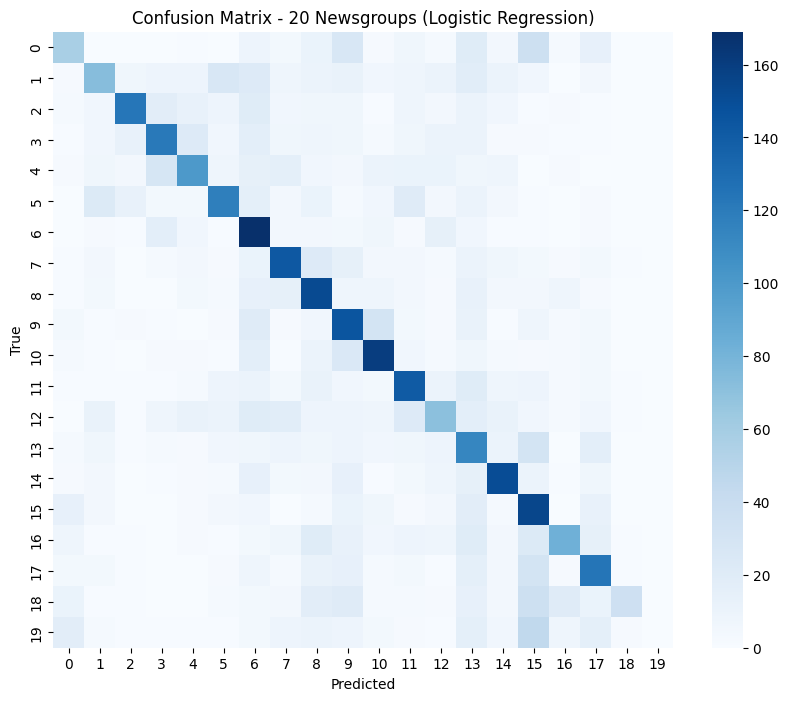

In [20]:
# 5. Ma trận nhầm lẫn
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=False, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - 20 Newsgroups (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Ví dụ B.4. (Bài tập thực hành 3)

In [23]:
file_data = 'D:/Workspace/HUS/Machine Learning/4. Softmax/glass.csv'
glass_df = pd.read_csv(file_data)
print(glass_df.info())
glass_types = glass_df['Type'].unique()
print(glass_types)

print(glass_df['Type'].value_counts())
X_1 = glass_df[glass_df.columns[:-1]]
y_1 = glass_df['Type']
X_train, X_test, y_train, y_test = train_test_split(X_1, y_1,

test_size=0.25,
random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id_Number  214 non-null    int64  
 1   RI         214 non-null    float64
 2   Na         214 non-null    float64
 3   Mg         214 non-null    float64
 4   Al         214 non-null    float64
 5   Si         214 non-null    float64
 6   K          214 non-null    float64
 7   Ca         214 non-null    float64
 8   Ba         214 non-null    float64
 9   Fe         214 non-null    float64
 10  Type       214 non-null    int64  
dtypes: float64(9), int64(2)
memory usage: 18.5 KB
None
[1 2 3 5 6 7]
Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_1, y_1, test_size=0.25, random_state=42, stratify=y_1
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (160, 10) | Test: (54, 10)


In [28]:
logreg = LogisticRegression(max_iter=8, multi_class='multinomial', solver='lbfgs')
logreg.fit(X_train, y_train)

C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 8 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=8).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,8
,multi_class,'multinomial'


In [29]:
y_pred = logreg.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy trên tập test: {acc:.4f}')

Accuracy trên tập test: 0.7037


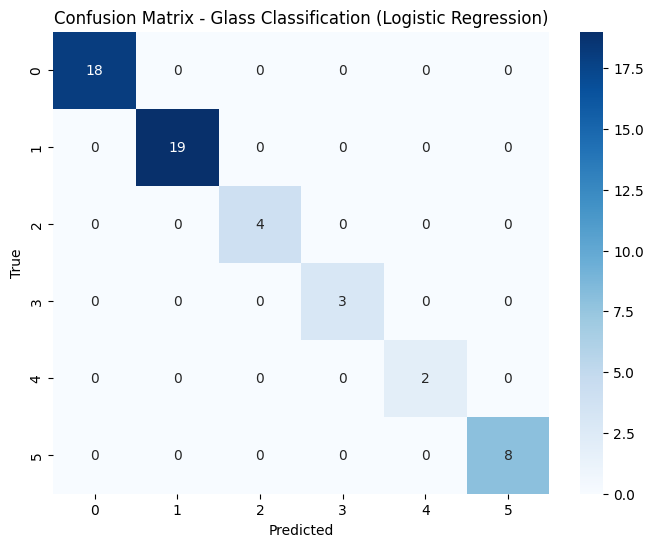

In [27]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Glass Classification (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Ví dụ 4

In [51]:
# train path
train_images_path = 'D:/Workspace/HUS/Machine Learning/4. Softmax/train-images-idx3-ubyte.gz'
train_labels_path = 'D:/Workspace/HUS/Machine Learning/4. Softmax/train-labels-idx1-ubyte.gz'
# test path
test_images_path = 'D:/Workspace/HUS/Machine Learning/4. Softmax/t10k-images-idx3-ubyte.gz'
test_labels_path = 'D:/Workspace/HUS/Machine Learning/4. Softmax/t10k-labels-idx1-ubyte.gz'

In [52]:
def get_mnist_data(images_path, labels_path, num_images, shuffle=False, _is=True, image_size=28):
    # read data
    # open file training to read training data
    f_images = gzip.open(images_path,'r')
    # skip 16 first bytes because these are not data, only header infor
    f_images.read(16)
    # general: read num_images data samples if this parameter is set;
    # if not, read all (60000 training or 10000 test)

    real_num = num_images if not shuffle else (60000 if _is else 10000)
    # read all data to buf_images (28x28xreal_num)
    buf_images = f_images.read(image_size * image_size * real_num)
    # images
    images = np.frombuffer(buf_images, dtype=np.uint8).astype(np.float32)
    images = images.reshape(real_num, image_size, image_size,)
    # Read labels
    f_labels = gzip.open(labels_path,'r')
    f_labels.read(8)
    labels = np.zeros((real_num)).astype(np.int64)
    # rearrange to correspond the images and labels
    for i in range(0, real_num):
        buf_labels = f_labels.read(1)
        labels[i] = np.frombuffer(buf_labels, dtype=np.uint8).astype(np.int64)
    # shuffle to get random images data
    if shuffle is True:
        rand_id = np.random.randint(real_num, size=num_images)
        images = images[rand_id, :]
        labels = labels[rand_id,]
    # change images data to type of vector 28x28 dimentional
    images = images.reshape(num_images, image_size * image_size)
    return images, labels

In [53]:
train_images, train_labels = get_mnist_data(train_images_path, train_labels_path, 5000, shuffle=True)
test_images, test_labels = get_mnist_data(test_images_path, test_labels_path, 10000, _is=False, shuffle=True)
print(train_images.shape, train_labels.shape)
print(test_images.shape, test_labels.shape)

(5000, 784) (5000,)
(10000, 784) (10000,)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18400\2201021911.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels[i] = np.frombuffer(buf_labels, dtype=np.uint8).astype(np.int64)


In [54]:
# Convert matrix to image
def get_image(image):
    return image.reshape(28, 28)
# These methods are from Vi du 1
def convert_labels(y, C):
    from scipy import sparse
    Y = sparse.coo_matrix((np.ones_like(y),
    (y, np.arange(len(y)))), shape = (C, len(y))).toarray()
    return Y
def softmax(Z):
    e_Z = np.exp(Z)
    A = e_Z / e_Z.sum(axis = 0)
    return A
def softmax_stable(Z):
    e_Z = np.exp(Z - np.max(Z, axis = 0, keepdims = True))
    A = e_Z / e_Z.sum(axis = 0)
    return A
def pred(W, X):
    A = softmax_stable(W.T.dot(X))
    return np.argmax(A, axis = 0)

In [55]:
def _softmax_regression(X, Y, theta, lambda_=0.5, iterations=20, learning_rate=1e-5, batch_size=200):
    from sklearn.metrics import log_loss
    losses = []
    _theta = theta
    d, N = X.shape
    for iter_ in range(iterations):
        shuffle_index = np.random.permutation(N)
        for i in shuffle_index:
            xi = X[:, i].reshape(d, 1)
            yi = Y[:, i].reshape(10, 1)
            ai = softmax_stable(np.dot(_theta.T, xi))
            _theta += learning_rate * xi.dot((yi - ai).T)
            if (iter_ * N + i) % batch_size == 0:
                Y_hat_prob = softmax_stable(np.dot(_theta.T, X))
                losses.append(log_loss(Y, Y_hat_prob))
        Y_hat_prob = softmax_stable(np.dot(_theta.T, X))
        print(f"epoch {iter_} - cost {log_loss(Y, Y_hat_prob) / N}")
    return _theta, losses

3 8


<Figure size 640x480 with 0 Axes>

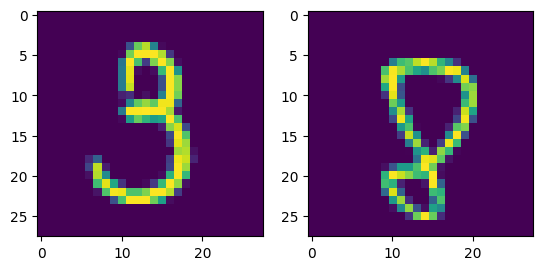

In [56]:

index = random.randint(0, 1000)
print(train_labels[index], test_labels[index])
train_image = np.asarray(get_image(train_images[index])).squeeze()
test_image = np.asarray(get_image(test_images[index])).squeeze()
plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 2)
# use the created array to output your multiple images. In this case I havestacked 4 images vertically
axarr[0].imshow(train_image)
axarr[1].imshow(test_image)
plt.show()

(785, 5000)
(10, 5000)


<Figure size 640x480 with 0 Axes>

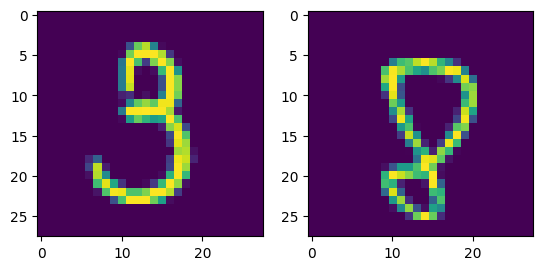

In [57]:
X_train = np.concatenate((np.ones((1, train_images.shape[0])), train_images.T),axis = 0)
Y_train = convert_labels(train_labels, 10)
print(X_train.shape)
print(Y_train.shape)
train_image = np.asarray(get_image(train_images[index])).squeeze()
test_image = np.asarray(get_image(test_images[index])).squeeze()
plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 2)
# use the created array to output your multiple images. In this case I havestacked 4 images vertically
axarr[0].imshow(train_image)
axarr[1].imshow(test_image)
plt.show()

In [ ]:
theta = np.zeros((X_train.shape[0], 10))

opt_theta, losses = _softmax_regression(X_train, Y_train, theta)

In [59]:
from sklearn.metrics import accuracy_score
print('accuracy training data: ', accuracy_score(train_labels,
pred(opt_theta, X_train)))

# test_images, test_labels = get_mnist_data(
# test_images_path, test_labels_path, 1000, _is=False, shuffle=False)
X_test = np.concatenate((np.ones((1, test_images.shape[0])), test_images.T), axis=0)

print(X_test.shape)
print('accuracy testing data: ', accuracy_score(test_labels,

pred(opt_theta, X_test)))

accuracy training data:  0.9212
(785, 10000)
accuracy testing data:  0.8518


In [ ]:
# import pandas as pd
# from sklearn.decomposition import PCA as sklearnPCA
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn import datasets
# # import some data to play with
# iris = datasets.load_iris()

# X = iris.data[:, :4] # we take full 4 features
# Y = iris.target
# # Normalize data
# X_norm = (X - X.min())/(X.max() - X.min())
# pca = sklearnPCA(n_components=2) #2-dimensional PCA
# transformed = pd.DataFrame(pca.fit_transform(X_norm))
# plt.axis("off")
# plt.scatter(transformed[Y==0][0], transformed[Y==0][1], s=9, label='IRIS Setosa',
# c='red')
# plt.scatter(transformed[Y==1][0], transformed[Y==1][1], s=9, label='IRIS Versicolor',
# c='green', marker="^")
# plt.scatter(transformed[Y==2][0], transformed[Y==2][1], s=9, label='IRIS Virginica',
# c='blue', marker="s")
# plt.legend()
# plt.show()
# Sử dụng đoạn code chọn số chiều chính trên đây, đưa tập dữ liệu của cell 28 đã đọc về còn 2 chiều, sau đó hiển thị lên màn hình để xem quan hệ giữa các lớp dữ liệu.

import pandas as pd
from sklearn.decomposition import PCA as sklearnPCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

